In [90]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import warnings

# Settings
plt.style.use("ggplot")
warnings.filterwarnings("ignore")

In [91]:
# Download daily close data
data = yf.download("SPY", period="10y", interval="1mo", auto_adjust=True)["Close"]

# Comptute log returns
returns = np.log(data / data.shift(1))
returns = returns["SPY"].dropna()

print(f"Sample mean (10y monthly log returns): {returns.mean()}")
print(f"Sample standard deviation:             {returns.std()}")

# Create blocks (keeping temporal structure)
N = 10
blocks = np.array_split(returns, N)

[*********************100%***********************]  1 of 1 completed

Sample mean (10y monthly log returns): 0.010987718821793039
Sample standard deviation:             0.04421777896768853


In [92]:
B = 10_000

rng = np.random.default_rng()

bootstrap_t = []
for b in range(B):
    idx = rng.integers(0, len(blocks), size=N)
    sampled_blocks = [blocks[i] for i in idx]
    sample = np.concatenate(sampled_blocks)
    bootstrap_t.append(sample.mean())

# Confidence intervals
intervals = [1.0, 99.0]
conf_intervals = np.percentile(bootstrap_t, intervals)

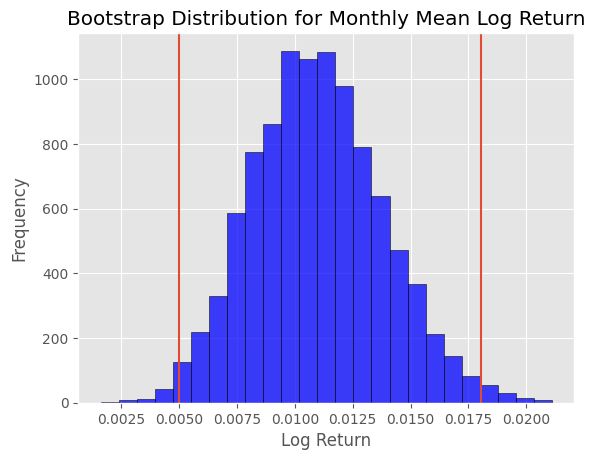

Bootstrap mean:           0.010989044719838328
Bootstrap standard error: 0.0028163409564357614
1.0% Confidence Interval: 0.00501140129758304
99.0% Confidence Interval: 0.018034133511057832


In [93]:
# Plot the bootstrap distribution
plt.hist(bootstrap_t, bins=25, color="blue", alpha=0.75, edgecolor="black")
plt.axvline(conf_intervals[0])
plt.axvline(conf_intervals[1])
plt.title("Bootstrap Distribution for Monthly Mean Log Return")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()

# Print bootstrap statistics
print(f"Bootstrap mean:           {np.mean(bootstrap_t)}")
print(f"Bootstrap standard error: {np.std(bootstrap_t)}")
print(f"{intervals[0]}% Confidence Interval: {conf_intervals[0]}")
print(f"{intervals[1]}% Confidence Interval: {conf_intervals[1]}")